# Introduction to GPSat

Last week covered Gaussian-process basics; this week we use **GPSat** and its model API—mainly how to read and tweak hyperparameters.

Run the code cells below to install the package.


Mount Drive here if you are on Colab. GPOD files and the HDF5 output path are assumed to live under Google Drive, so this step is what makes them visible to the runtime.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Install **gpflow**; the GP run later uses `GPflowGPRModel`, which sits on top of GPflow.


In [2]:
!pip install gpflow

This block detects Colab, clones GPSat into `/content`, and `cd`s into the repo so the next `pip` commands and `import GPSat` hit the right tree.


In [3]:
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

# TODO: allow for mounting of gdrive
# TODO: allow for checking out a branch

if IN_COLAB:

    import os
    import re

    # change to working directory
    work_dir = "/content"

    assert os.path.exists(work_dir), f"workspace directory: {work_dir} does not exist"
    os.chdir(work_dir)

    # clone repository
    !git clone https://github.com/CPOMUCL/GPSat.git

    repo_dir = os.path.join(work_dir, "GPSat")

    print(f"changing directory to: {repo_dir}")
    os.chdir(repo_dir)

Cloning into 'GPSat'...
remote: Enumerating objects: 2901, done.
remote: Counting objects: 100% (307/307), done.
remote: Compressing objects: 100% (141/141), done.
remote: Total 2901 (delta 151), reused 286 (delta 147), pack-reused 2594 (from 1)
Receiving objects: 100% (2901/2901), 62.43 MiB | 17.63 MiB/s, done.
Resolving deltas: 100% (1966/1966), done.
changing directory to: /content/GPSat


Install everything in `requirements.txt` from the clone—fills in the remaining GPSat dependencies.


In [4]:
if IN_COLAB:
    !pip install -r requirements.txt

Ignoring tensorflow: markers 'platform_system == "Darwin" and platform_machine == "x86_64"' don't match your environment
Ignoring tensorflow-macos: markers 'platform_system == "Darwin" and platform_machine == "arm64"' don't match your environment
Ignoring gpflow: markers 'platform_system == "Darwin" and platform_machine == "arm64"' don't match your environment
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 125.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip

`pip install -e .` puts GPSat in editable mode so Python imports the folder you just cloned instead of an older wheel somewhere else.


In [5]:
if IN_COLAB:
    !pip install -e .

Obtaining file:///content/GPSat
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Using cached pandas-1.5.3.tar.gz (5.2 MB)
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


Install `deprecated`, then pull in NumPy / SciPy / Matplotlib / `sklearnGPRModel`. 

In [6]:
!pip install deprecated

import numpy as np
import scipy
import matplotlib.pyplot as plt
from GPSat.models.sklearn_models import sklearnGPRModel

/content/GPSat/GPSat/utils.py:999: SyntaxWarning: invalid escape sequence '\*'
  branch = [re.sub(r"^\* ", "", b) for b in branches if re.search("^\*", b)][0]
/content/GPSat/GPSat/utils.py:1998: SyntaxWarning: invalid escape sequence '\.'
  return re.sub("^<__main__\.| object at .*$", "", out)


From here onward it is the same along-track story as in class, except the field I model is **radar freeboard** (GPOD column 4), not interpolated SLA.


# GPSat Along-Track Interpolation

What I do in this section:

- Pull **along-track** GPOD fields—class, radar freeboard, coordinates, time—for leads and floes.
- Run GPSat’s **local-expert** GP interpolation so every footprint on the chosen track gets a predicted freeboard.
- **Compare** those predictions to the observations (maps and along-track plots).
- **See** where the GP drifts from the data and whether that tracks with distance along the orbit or surface type.

Same workflow as the SLA example from lectures, but the observation column in the model is **radar freeboard**.


Install **Cartopy**; the polar figures below need its projections and coastlines.


In [7]:
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 131.6 MB/s eta 0:00:00


Install **dataclasses-json**—GPSat leans on it when configuration objects get serialised.


In [9]:
!pip install dataclasses-json

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 6.0 MB/s eta 0:00:00


Big import cell: standard libraries, GPSat helpers, Cartopy, and `GCdist` for great-circle distance along the track. There is a second `pip install dataclasses-json` tucked inside if the earlier cell did not stick.


In [10]:
import os
import re
import glob
import numpy as np
import pandas as pd
import warnings
# warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeat

from datetime import datetime, timedelta
from GPSat import get_data_path, get_parent_path
from GPSat.dataprepper import DataPrep
from GPSat.utils import WGS84toEASE2_New, EASE2toWGS84_New, cprint, grid_2d_flatten, get_weighted_values
# Install missing dependency
!pip install dataclasses-json
from GPSat.local_experts import LocalExpertOI, get_results_from_h5file
from GPSat.plot_utils import plot_pcolormesh, get_projection, plot_pcolormesh_from_results_data
from GPSat.postprocessing import smooth_hyperparameters
import GPSat
from GPSat.postprocessing import glue_local_predictions_1d
from GPSat.postprocessing import glue_local_predictions_2d


def GCdist(X,Xs):
    radius = lambda lat : np.sqrt(((6378137**2 * np.cos(lat))**2 + (6356752**2 * np.sin(lat))**2/\
                                  (6378137 * np.cos(lat))**2 + (6356752 * np.sin(lat))**2))

    minlat = min(np.min(X.T[(1,)].T),np.min(Xs.T[(1,)].T))
    maxlat = max(np.max(X.T[(1,)].T),np.max(Xs.T[(1,)].T))
    lon1 = np.radians(X.T[(0,)].T) ; lat1 = np.radians(X.T[(1,)].T)
    lon2 = np.radians(Xs.T[(0,)].T) ; lat2 = np.radians(Xs.T[(1,)].T)
    r = 6356752#np.mean(radius(np.arange(minlat,maxlat)))

    Clat1 = np.cos(lat1) ; Clat2 = np.cos(lat2)
    Slat1 = np.sin(lat1) ; Slat2 = np.sin(lat2)
    Clon1 = np.cos(lon1) ; Clon2 = np.cos(lon2)
    Slon1 = np.sin(lon1) ; Slon2 = np.sin(lon2)

    n1 = np.array([Clat1*Clon1,Clat1*Slon1,Slat1]).T
    n2 = np.array([Clat2*Clon2,Clat2*Slon2,Slat2]).T
    return r*np.arccos(np.dot(n1,n2.T))

/content/GPSat/GPSat/postprocessing.py:255: SyntaxWarning: invalid escape sequence '\d'
  dim_cols = [c for c in df.columns if re.search("^_dim_\d", c)]
/content/GPSat/GPSat/postprocessing.py:352: SyntaxWarning: invalid escape sequence '\.'
  out_config = re.sub("\.h5$", f"{reference_table_suffix}{table_suffix}.json", result_file)


Loads the GPOD `*v1.proc` files: column legend at the top, filter by ice concentration, tag leads vs floes, push lon/lat through EASE-2, turn dates into a numeric time axis, then stack the tracks that fall in the window into `df`.


In [12]:
#indices for GPOD data:
#0 = Lon
#1 = Lat
#2 = Interpolated SLA
#3 = Error in interpolated SLA
#4 = Freeboard
#5 = Pulse Peakiness
#6 = Lew
#7 = Class (1=Lead, 2=Floe, 3=OO)
#8 = Sigma 0
#9 = Raw Elevation
#10 = Mean Sea-surface
#11 = SIC
#12 = Sea ice type (0=FYI, 1=MYI)
#13 = Snow depth
#14 = Snow density
#15 = Sea ice thickness
#16 = GPOD SLA
#17 = GPOD SSH
#18 = GPOD SWH
#19 = Elevation from Samosa

def process_track(track, grab_dates, satellite, count):
    """ Process a single track file if it falls on a date of interest """
    date = track.split('/')[-1].split('T')[0].split('_')[-1]
    if date in grab_dates:
        time = 14975 + (datetime.strptime(date, '%Y%m%d') - datetime(2011, 1, 1)).days
        f = np.genfromtxt(track)

        ID = np.where((f[:, 7] < 3) & (f[:, 11] >= 0.75))[0]
        classes = np.where(f[ID, 7] == 1.0, 'lead', 'floe')

        elvmss = f[ID, 9] - f[ID, 10]
        elvmss[classes == 'floe'] -= 0.1626  # Apply bias correction (see Lawrence et al., 2019)

        xg, yg = WGS84toEASE2_New(f[ID, 0], f[ID, 1])
        N = len(xg)

        # Initialise dataframe to store retrieved track data
        track_df = pd.DataFrame()

        track_df['x']= xg
        track_df['y'] = yg
        track_df['t'] = [time] * N
        track_df['lon'] = f[ID, 0]
        track_df['lat'] = f[ID, 1]
        track_df['date'] = [date] * N
        track_df['class'] = classes
        track_df['radar_freeboard'] = f[ID, 4]
        track_df['elevation'] = elvmss
        track_df['SAT'] = [satellite] * N
        track_df['track'] = [count] * N
        return count + 1, track_df

    return count, None

# Generate date range
interp_date = datetime(2019, 1, 15)
grab_dates = [(interp_date - timedelta(days=x)).strftime('%Y%m%d') for x in range(5)] + \
             [(interp_date + timedelta(days=x)).strftime('%Y%m%d') for x in range(1, 5)]

# Path to directories
# dirs = sorted(glob.glob('/Users/wg4031/Dropbox/GPOD_DATA/*'))
# dirs = sorted(glob.glob('/content/drive/MyDrive/0069/week7/GPOD/*'))
dirs = sorted(glob.glob('/content/drive/MyDrive/0069/week7/GPOD/*'))

# Process tracks
track_dfs = []
count = 0
for directory in dirs:
    satellite = directory.split('/')[-1]
    if satellite in {'SARIN', 'SAR'}:
        satellite = 'CS2'
    for track in sorted(glob.glob(f"{directory}/*v1.proc")):
        count, track_df = process_track(track, grab_dates, satellite, count)
        if track_df is not None:
            track_dfs.append(track_df)

#Create a single dataframe for all tracks
df = pd.concat(track_dfs, ignore_index=True)
df

/tmp/ipykernel_3973/3793597009.py:36: DeprecationWarning: Call to deprecated function (or staticmethod) WGS84toEASE2_New. (This function will be removed in future versions. Use `WGS84toEASE2` instead.)
  xg, yg = WGS84toEASE2_New(f[ID, 0], f[ID, 1])
/tmp/ipykernel_3973/3793597009.py:36: DeprecationWarning: Call to deprecated function (or staticmethod) WGS84toEASE2_New. (This function will be removed in future versions. Use `WGS84toEASE2` instead.)
  xg, yg = WGS84toEASE2_New(f[ID, 0], f[ID, 1])
/tmp/ipykernel_3973/3793597009.py:36: DeprecationWarning: Call to deprecated function (or staticmethod) WGS84toEASE2_New. (This function will be removed in future versions. Use `WGS84toEASE2` instead.)
  xg, yg = WGS84toEASE2_New(f[ID, 0], f[ID, 1])
/tmp/ipykernel_3973/3793597009.py:36: DeprecationWarning: Call to deprecated function (or staticmethod) WGS84toEASE2_New. (This function will be removed in future versions. Use `WGS84toEASE2` instead.)
  xg, yg = WGS84toEASE2_New(f[ID, 0], f[ID, 1])


,x,y,t,lon,lat,date,class,radar_freeboard,elevation,SAT,track
0,-3.056178e+06,-1.270463e+06,17907,-67.427184,60.000844,20190111,lead,NaN,0.4397,S3A,0
1,-3.055943e+06,-1.270243e+06,17907,-67.429148,60.003653,20190111,lead,NaN,0.4250,S3A,0
2,-3.055707e+06,-1.270022e+06,17907,-67.431112,60.006463,20190111,lead,NaN,0.4296,S3A,0
3,-3.055472e+06,-1.269801e+06,17907,-67.433077,60.009272,20190111,lead,NaN,0.4494,S3A,0
4,-3.055236e+06,-1.269580e+06,17907,-67.435042,60.012081,20190111,lead,NaN,0.4171,S3A,0
...,...,...,...,...,...,...,...,...,...,...,...
1559080,-1.099325e+06,3.126184e+05,17915,-105.874325,79.752732,20190119,floe,0.2953,0.2087,CS2,653
1559081,-1.099022e+06,3.125989e+05,17915,-105.877535,79.755398,20190119,lead,NaN,-0.1044,CS2,653
1559082,-1.098114e+06,3.125402e+05,17915,-105.887172,79.763397,20190119,floe,NaN,0.2351,CS2,653
1559083,-1.097811e+06,3.125207e+05,17915,-105.890387,79.766064,20190119,floe,NaN,0.3295,CS2,653


Pick a single orbit with `interptrack`, build `df_val`, and map radar freeboard on a North Polar stereographic basemap so I can eyeball one track before modelling.


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


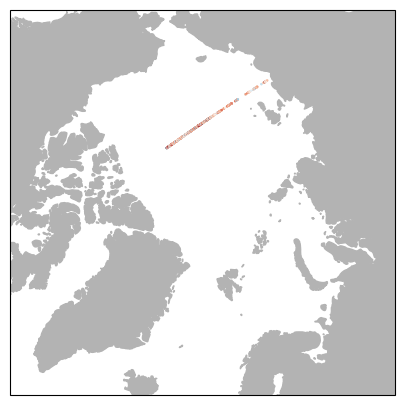

,x,y,t,lon,lat,date,class,radar_freeboard,elevation,SAT,track
3051,-546016.208513,7.870765e+05,17907,-145.249909,81.414978,20190111,floe,NaN,0.0247,S3A,1
3052,-545744.788692,7.872712e+05,17907,-145.269889,81.414930,20190111,floe,NaN,0.1204,S3A,1
3053,-545473.353742,7.874660e+05,17907,-145.289868,81.414880,20190111,floe,NaN,0.2833,S3A,1
3054,-545201.932777,7.876608e+05,17907,-145.309847,81.414830,20190111,floe,NaN,0.2403,S3A,1
3055,-544930.498775,7.878555e+05,17907,-145.329826,81.414779,20190111,floe,NaN,0.1529,S3A,1
...,...,...,...,...,...,...,...,...,...,...,...
6054,985661.345909,1.804912e+06,17907,151.361068,71.501454,20190111,lead,NaN,-0.1594,S3A,1
6055,985942.928513,1.805084e+06,17907,151.356490,71.498852,20190111,lead,NaN,-0.1119,S3A,1
6056,986224.515088,1.805257e+06,17907,151.351913,71.496250,20190111,lead,NaN,-0.0875,S3A,1
6057,986506.099320,1.805430e+06,17907,151.347337,71.493648,20190111,lead,NaN,-0.1143,S3A,1


In [13]:
interptrack = 1 #select the 2nd track loaded within the specified date range around our interp date
df_val = df.loc[df['track']==interptrack]

fig,ax = plt.subplots(1,figsize=(5,5),subplot_kw=dict(projection=ccrs.NorthPolarStereo()))
ax.set_extent([-180,180,65,90],ccrs.PlateCarree())
ax.add_feature(cfeat.LAND, color=(0.7,0.7,0.7))
ax.scatter(df_val['lon'],df_val['lat'],s=0.5,c=df_val['radar_freeboard'],cmap='RdBu_r',vmin=-0.3,vmax=0.3,transform=ccrs.PlateCarree())
plt.show()

df_val

Quick sanity check: plot radar freeboard against along-track index for leads and floes separately—does the split look sensible?


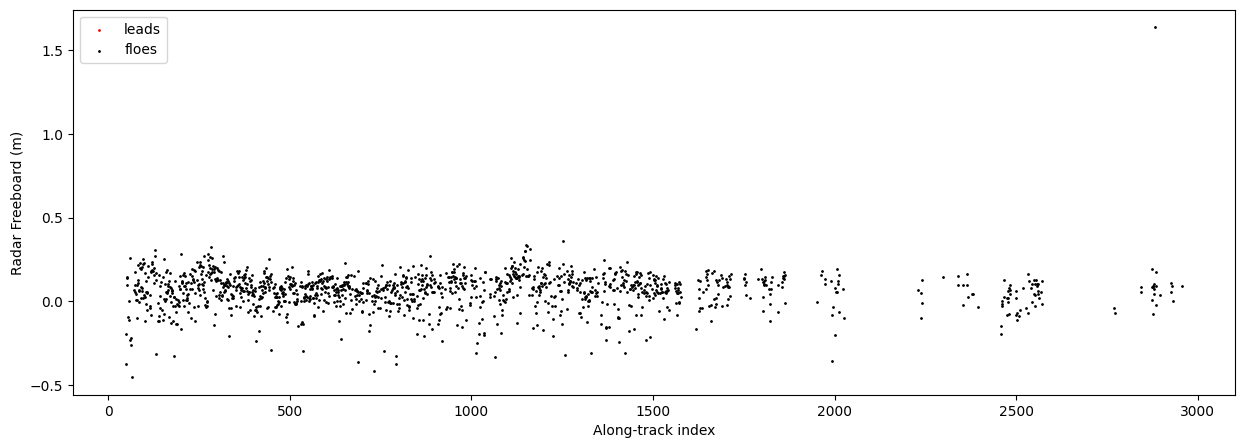

In [14]:
leads = np.where(df_val['class'] == 'lead')[0]
floes = np.where(df_val['class'] == 'floe')[0]

fig, ax = plt.subplots(1, figsize=(15, 5))
ax.scatter(leads, df_val['radar_freeboard'].iloc[leads], color='r', s=1, label='leads')
ax.scatter(floes, df_val['radar_freeboard'].iloc[floes], color='k', s=1, label='floes')
ax.set_ylabel('Radar Freeboard (m)')
ax.set_xlabel('Along-track index')
ax.legend()
plt.show()

Work out cumulative distance from the first footprint, place expert anchors roughly every 100 km (capped at 16), plot the full swath vs the anchor points, and keep `experts` for `LocalExpertOI`.


/tmp/ipykernel_3973/805701050.py:44: RuntimeWarning: invalid value encountered in arccos
  return r*np.arccos(np.dot(n1,n2.T))
/tmp/ipykernel_3973/3066607700.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_val['dist_along_track'] = r_exp[0,:]


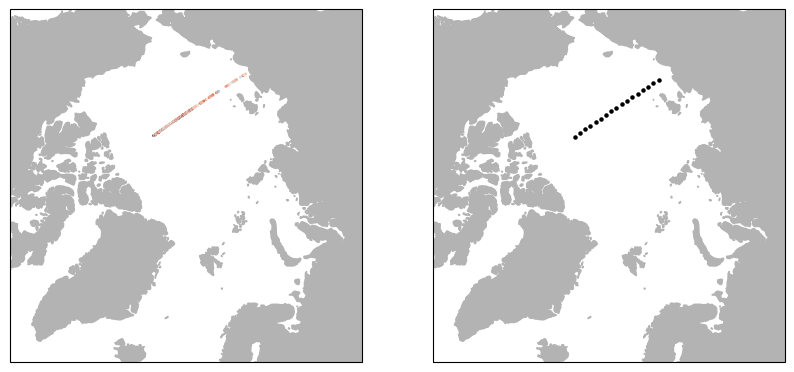

,x,y,t,lon,lat,date,class,radar_freeboard,elevation,SAT,track,dist_along_track
3051,-546016.208513,7.870765e+05,17907,-145.249909,81.414978,20190111,floe,NaN,0.0247,S3A,1,0.000000e+00
3265,-463933.092598,8.457381e+05,17907,-151.252849,81.354797,20190111,floe,0.0764,0.1921,S3A,1,9.994286e+04
3492,-381627.223432,9.040727e+05,17907,-157.114416,81.204893,20190111,floe,0.1376,0.2990,S3A,1,1.998845e+05
3690,-299105.371262,9.620754e+05,17907,-162.729741,80.969739,20190111,floe,-0.0298,0.1433,S3A,1,2.998243e+05
3825,-216099.960293,1.019932e+06,17907,-168.037266,80.654613,20190111,floe,0.0957,0.2485,S3A,1,4.000924e+05
3990,-133165.724552,1.077256e+06,17907,-172.953091,80.269255,20190111,floe,0.1474,0.2677,S3A,1,5.000264e+05
4192,-49760.137359,1.134422e+06,17907,-177.488394,79.819258,20190111,floe,0.1641,0.2515,S3A,1,6.002874e+05
4381,33283.280733,1.190861e+06,17907,178.399061,79.317314,20190111,floe,-0.3065,-0.2437,S3A,1,6.998821e+05
4565,116230.866694,1.246762e+06,17907,174.673926,78.769895,20190111,floe,0.0522,0.1048,S3A,1,7.991409e+05
4655,201015.684995,1.303415e+06,17907,171.232783,78.169840,20190111,lead,NaN,0.0139,S3A,1,9.003789e+05


In [15]:
#divide track into 200 km points for expert locations
Xs = np.array([df_val['lon'],df_val['lat']]).T
r_exp = GCdist(Xs,Xs) #compute distance matrix
df_val['dist_along_track'] = r_exp[0,:]
exp_grid = np.arange(0,np.sum(r_exp[0,:]),100e3)
locs = []
for ix in exp_grid:
    temp = np.abs(r_exp[0,:]-ix)
    dm = np.where(temp==np.min(temp))
    if len(locs)<=16:
        locs.append(dm[0][0])

fig,ax = plt.subplots(1,2,figsize=(10,5),subplot_kw=dict(projection=ccrs.NorthPolarStereo()))
for c in range(2):
    ax[c].set_extent([-180,180,65,90],ccrs.PlateCarree())
    ax[c].add_feature(cfeat.LAND, color=(0.7,0.7,0.7))
    if c == 0:
        ax[c].scatter(df_val['lon'],df_val['lat'],c=df_val['radar_freeboard'],s=0.5,cmap='RdBu_r',vmin=-0.3,vmax=0.3,transform=ccrs.PlateCarree())
    else:
        ax[c].scatter(df_val['lon'].iloc[locs],df_val['lat'].iloc[locs],s=5,c='k',transform=ccrs.PlateCarree())
plt.show()

experts = df_val.iloc[locs]
experts

The heavy lift: wire up `LocalExpertOI`, train on valid freeboard observations, smooth hyperparameters in space, rerun prediction with the smoothed settings, write HDF5, and optionally run `ptrepack` to compress the store.


In [16]:
store_path = get_parent_path("/content/drive/MyDrive/0067/week7/", "GPSatSVGP_CS2S3_alongtrack_radar_freeboard.h5")

if os.path.exists(store_path):
    print("removing previous results")
    os.remove(store_path)

data = {

    "data_source": df.loc[(~np.isnan(df['radar_freeboard'])) & (np.abs(df['radar_freeboard']) < 0.6)],

    "obs_col": "radar_freeboard",
    "coords_col": ["x", "y", "t"],
    "local_select": [
        {"col": ["x", "y"], "comp": "<=", "val": 100_000},
        {"col": "t", "comp": "<=", "val": 2},
        {"col": "t", "comp": ">=", "val": -2}
    ],
    "global_select": [
        {"col": "lat", "comp": ">=", "val": 45}
    ]
}

#GIVE DATAFRAME OF EXPERTS
local_expert = {
    "source": experts
}

#GIVE DATAFRAME OF PREDICTION LOCATIONS (predict at all lead and floe locations along track)
pred_loc = {
    "method": "from_dataframe",
    "df": df_val,
    "max_dist": 200_000
}


#SETUP SPARSE GP MODEL (PLAY WITH MINIBATCH AND INDUCING POINTS)
model = {
    # "oi_model": "GPflowSVGPModel",
    "oi_model": "GPflowGPRModel",
    "init_params": {
        # scale (divide) coordinates
        "coords_scale": [10000, 10000, 1],
        "minibatch_size": 100,
        "num_inducing_points":200
    },
    "constraints": {
        # lengthscales - same order coord_col (see data)
        "lengthscales": {
            "low": [100_000, 100_000, 1e-08],
            # "low": [5_000, 5_000, 1e-08],
            "high": [200000, 200000, 4]
            },
            "likelihood_variance": {
                "low": 0.01,
                "high": 10
        }
    }
}

locexp = LocalExpertOI(expert_loc_config=local_expert,
                       data_config=data,
                       model_config=model,
                       pred_loc_config=pred_loc)

# run optimal interpolation
locexp.run(store_path=store_path,
           optimise=True)

#SMOOTH HYPERPARMETERS
smooth_configs = {"lengthscales": dict(l_x=200_000, l_y=200_000, max=12),
                  "likelihood_variance": dict(l_x=200_000, l_y=200_000),
                  "kernel_variance": dict(l_x=200_000, l_y=200_000, max=0.1)}

smooth_hyperparameters(result_file=store_path,
                       params_to_smooth=["lengthscales", "kernel_variance", "likelihood_variance"],
                       smooth_config_dict=smooth_configs,
                       save_config_file=False)

# %%
# ---
# Make predictions with smoothed hyperparameters
# ---
model['load_params'] = {"file": store_path, "table_suffix": "_SMOOTHED"}
locexp = LocalExpertOI(expert_loc_config=local_expert,
                       data_config=data,
                       model_config=model,
                       pred_loc_config=pred_loc)

locexp.run(store_path=store_path,
           optimise=False,
           predict=True,
           table_suffix='_SMOOTHED')

os.system('ptrepack --chunkshape=auto --propindexes --complib=blosc '+store_path+' temp_store_3D.csv')
os.system('rm '+store_path)
os.system('mv temp_store_3D.csv '+store_path)

print('Done!')

'data_select': 0.001 seconds
'load': 0.001 seconds
in json_serializable - key: 'data_source' has value DataFrame/Series, but is too long: 787686 >  100
storing as str


/content/GPSat/GPSat/models/gpflow_models.py:688: SyntaxWarning: invalid escape sequence '\['
  \[T'09\] Titsias, Michalis. "Variational learning of inducing variables in sparse Gaussian processes." Artificial intelligence and statistics. PMLR, 2009.
/content/GPSat/GPSat/models/gpflow_models.py:927: SyntaxWarning: invalid escape sequence '\['
  \[H'13\] Hensman, James, Nicolo Fusi, and Neil D. Lawrence. "Gaussian processes for big data." arXiv preprint arXiv:1309.6835 (2013).


in json_serializable - key: 'df' has value DataFrame/Series, but is too long: 3008 >  100
storing as str
---------
storing expert locations in 'expert_locs' table
exception occurred: 'No object named expert_locs in the file'
will now close object

---------
dropping expert locations that already exists in 'run_details' table
exception occurred: 'No object named run_details in the file'
will now close object

--------------------------------------------------
1 / 17
current local expert:
                  x              y      t         lon        lat      date  \
3051 -546016.208513  787076.451694  17907 -145.249909  81.414978  20190111   

     class  radar_freeboard  elevation  SAT  track  dist_along_track  
3051  floe              NaN     0.0247  S3A      1               0.0  


/usr/local/lib/python3.12/dist-packages/tables/path.py:146: NaturalNameWarning: object name is a Python keyword: 'class'; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)


'data_select': 0.235 seconds
'load': 0.235 seconds
'local_data_select': 0.268 seconds
number obs: 3307
found GPU
setting lengthscales to: [1. 1. 1.]
'__init__': 2.726 seconds
'get_parameters': 0.008 seconds
'set_lengthscales_constraints': 0.014 seconds
'set_likelihood_variance_constraints': 0.093 seconds
'optimise_parameters': 5.008 seconds
'get_parameters': 0.006 seconds
parameters:
lengthscales: array([10.00454664, 10.00000868,  3.99999996]) 
kernel_variance: 0.3645003738066924
likelihood_variance: 0.010439408490748845
'predict': 0.102 seconds
total run time : 8.92 seconds
--------------------------------------------------
2 / 17
current local expert:
                  x              y      t         lon        lat      date  \
3265 -463933.092598  845738.103282  17907 -151.252849  81.354797  20190111   

     class  radar_freeboard  elevation  SAT  track  dist_along_track  
3265  floe           0.0764     0.1921  S3A      1      99942.861425  
'local_data_select': 0.266 seconds
numb

/usr/local/lib/python3.12/dist-packages/tables/path.py:146: NaturalNameWarning: object name is a Python keyword: 'class'; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)


'data_select': 0.233 seconds
'load': 0.233 seconds
'local_data_select': 0.267 seconds
number obs: 3307
found GPU
setting lengthscales to: [1. 1. 1.]
'__init__': 0.039 seconds
'get_parameters': 0.007 seconds
'_read_params_from_file': 0.093 seconds
'set_parameters': 0.011 seconds
'set_lengthscales_constraints': 0.010 seconds
'set_likelihood_variance_constraints': 0.030 seconds
*** not optimising parameters
'get_parameters': 0.006 seconds
parameters:
lengthscales: array([10.0888275 , 10.03473296,  3.92861171]) 
kernel_variance: 0.06782886421821789
likelihood_variance: 0.01999999999999999
'predict': 0.093 seconds
total run time : 1.21 seconds
--------------------------------------------------
2 / 17
current local expert:
                  x              y      t         lon        lat      date  \
3265 -463933.092598  845738.103282  17907 -151.252849  81.354797  20190111   

     class  radar_freeboard  elevation  SAT  track  dist_along_track  
3265  floe           0.0764     0.1921  S3A  

Read the HDF5 back into `dfs` so I can grab the smoothed prediction tables next.


In [17]:
# extract, store in dict
# store_path = "/content/drive/MyDrive/AI4EO/Week 8/GPSatSVGP_CS2S3_alongtrack_SLA_3D.h5"
dfs, _ = GPSat.local_experts.get_results_from_h5file(store_path)

reading in results
getting all tables
merging on expert location data
table: 'oi_config' does not have all coords_col: ['x', 'y', 't'] in columns, not merging on expert_locations
table: 'oi_config_SMOOTHED' does not have all coords_col: ['x', 'y', 't'] in columns, not merging on expert_locations


Import the glue helpers from `GPSat.postprocessing`; the next cell averages overlapping expert predictions in 2D.


In [18]:
from GPSat.postprocessing import glue_local_predictions

Pull `preds_SMOOTHED` and print `head()`—sanity-check column names and a few rows.


In [19]:
preds_data = dfs["preds_SMOOTHED"]

preds_data.head()

,x,y,t,_dim_0,f*,f*_var,y_var,f_bar,pred_loc_x,pred_loc_y,pred_loc_t,lon,lat,date,class,radar_freeboard,elevation,SAT,track,dist_along_track
0,-546016.208513,787076.451694,17907.0,0,0.147566,0.000722,0.020722,0,-546016.208513,787076.451694,17907.0,-145.249909,81.414978,20190111,floe,NaN,0.0247,S3A,1,0.0
1,-546016.208513,787076.451694,17907.0,1,0.145581,0.000735,0.020735,0,-545744.788692,787271.231607,17907.0,-145.249909,81.414978,20190111,floe,NaN,0.0247,S3A,1,0.0
2,-546016.208513,787076.451694,17907.0,2,0.143586,0.000749,0.020749,0,-545473.353742,787466.002222,17907.0,-145.249909,81.414978,20190111,floe,NaN,0.0247,S3A,1,0.0
3,-546016.208513,787076.451694,17907.0,3,0.141584,0.000762,0.020762,0,-545201.932777,787660.770465,17907.0,-145.249909,81.414978,20190111,floe,NaN,0.0247,S3A,1,0.0
4,-546016.208513,787076.451694,17907.0,4,0.139574,0.000775,0.020775,0,-544930.498775,787855.541507,17907.0,-145.249909,81.414978,20190111,floe,NaN,0.0247,S3A,1,0.0


Run `glue_local_predictions_2d` with a 200 km inference radius so overlapping expert patches merge into one field, `plt_data`.


In [20]:
# # multiple local experts may make predictions at the same prediction location (pred_loc).
# # - for each prediction at a given location, take we weighted combination
# # - weights being a function of the distance to each local expert that made a prediction at a given location.

inference_radius = 200_000  # 200km
plt_data = glue_local_predictions_2d(preds_df=preds_data,
                                     pred_loc_cols=["pred_loc_x", "pred_loc_y"],
                                     xprt_loc_cols=["x", "y"],
                                     vars_to_glue=["f*", "f*_var"],
                                     inference_radius=inference_radius)

Join the glued GP means to `df_val` on projected x–y, keep the observation columns, and define `rfb_diff` as observed radar freeboard minus the GP mean.


In [25]:
# Merge glued predictions with along-track observations.


rfb_df = pd.merge(
    df_val[['lon', 'lat', 'x', 'y', 'radar_freeboard', 'dist_along_track', 'class']],
    plt_data[['pred_loc_x', 'pred_loc_y', 'f*']],
    left_on=['x', 'y'],
    right_on=['pred_loc_x', 'pred_loc_y']
)

# Observation minus GP mean (residual).
rfb_df['rfb_diff'] = rfb_df['radar_freeboard'] - rfb_df['f*']
rfb_df

,lon,lat,x,y,radar_freeboard,dist_along_track,class,pred_loc_x,pred_loc_y,f*,rfb_diff
0,-145.249909,81.414978,-546016.208513,7.870765e+05,NaN,0.000000e+00,floe,-546016.208513,7.870765e+05,0.134766,NaN
1,-145.269889,81.414930,-545744.788692,7.872712e+05,NaN,3.309358e+02,floe,-545744.788692,7.872712e+05,0.132926,NaN
2,-145.289868,81.414880,-545473.353742,7.874660e+05,NaN,6.618785e+02,floe,-545473.353742,7.874660e+05,0.131080,NaN
3,-145.309847,81.414830,-545201.932777,7.876608e+05,NaN,9.928085e+02,floe,-545201.932777,7.876608e+05,0.129228,NaN
4,-145.329826,81.414779,-544930.498775,7.878555e+05,NaN,1.323751e+03,floe,-544930.498775,7.878555e+05,0.127370,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2977,151.862624,71.781861,955257.667849,1.786233e+06,NaN,1.792640e+06,lead,955257.667849,1.786233e+06,0.009463,NaN
2978,151.857915,71.779270,955539.129893,1.786406e+06,NaN,1.792970e+06,lead,955539.129893,1.786406e+06,0.009430,NaN
2979,151.853207,71.776679,955820.569170,1.786580e+06,NaN,1.793301e+06,lead,955820.569170,1.786580e+06,0.009397,NaN
2980,151.839091,71.768906,956664.886400,1.787099e+06,NaN,1.794292e+06,lead,956664.886400,1.787099e+06,0.009299,NaN


Along-track plot: scatter leads and floes, overlay observed freeboard and the GP curve against distance—easy to read off agreement and outliers.


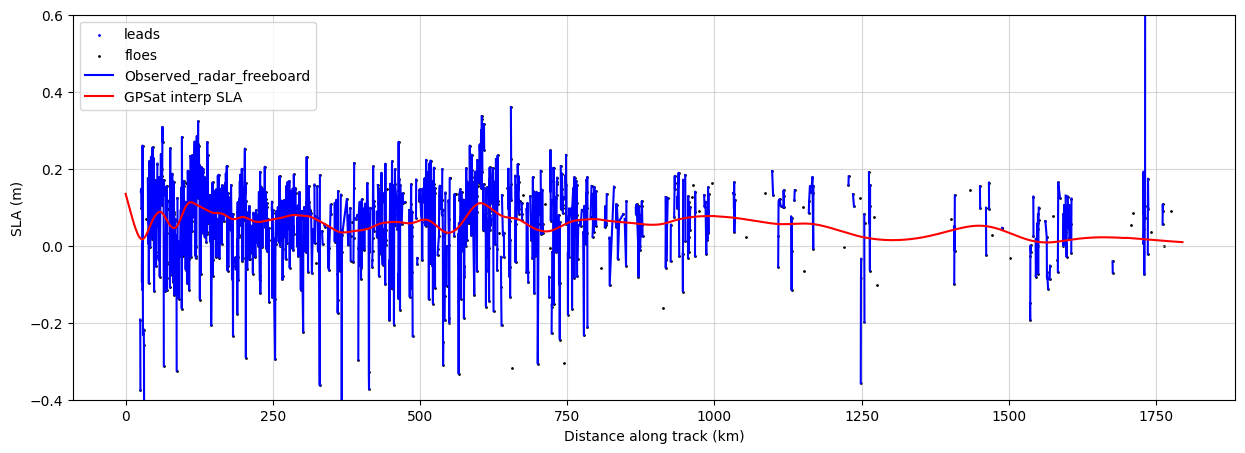

In [27]:
leads_df = rfb_df[rfb_df['class'] == 'lead']
floes_df = rfb_df[rfb_df['class'] == 'floe']

fig,ax = plt.subplots(1,figsize=(15,5))
ax.grid(True, alpha=0.5)
ax.scatter(leads_df['dist_along_track']/1000,leads_df['radar_freeboard'],color='b',s=1,label='leads')
ax.scatter(floes_df['dist_along_track']/1000,floes_df['radar_freeboard'],color='k',s=1,label='floes')
ax.plot(rfb_df['dist_along_track']/1000,rfb_df['radar_freeboard'],color='b',label='Observed_radar_freeboard')
ax.plot(rfb_df['dist_along_track']/1000,rfb_df['f*'],color='r',label='GPSat radar freeboard')
ax.set_ylim(-0.4,0.6)
ax.set_ylabel('Radar freeboard (m)')
ax.set_xlabel('Distance along track (km)')
ax.legend()
plt.show()

Four tight Arctic panels: observed freeboard, GP freeboard, their difference, and distance along track (I narrowed the latitude band to zoom in on the ice edge).


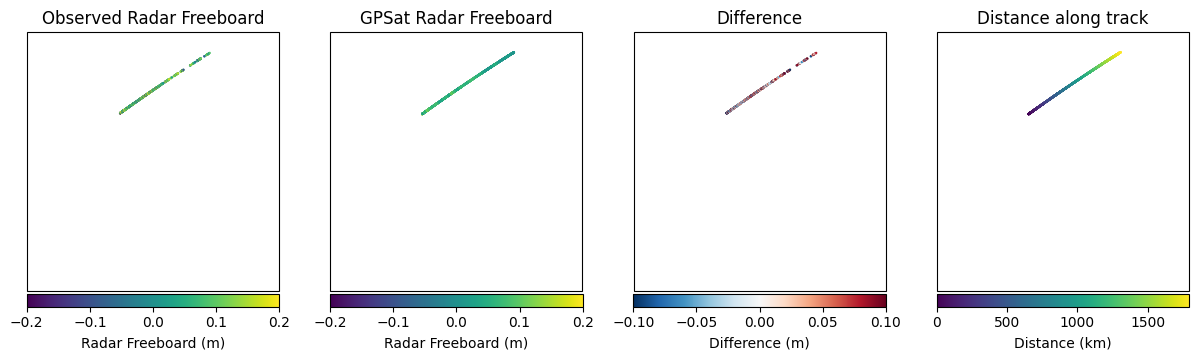

In [28]:
fig, axs = plt.subplots(1, 4, figsize=(15, 4), subplot_kw={'projection': ccrs.NorthPolarStereo()})

for ax in axs:
    ax.set_extent([-180, 180, 71, 72.5], ccrs.PlateCarree())

# Plot observed radar freeboard
obs = axs[0].scatter(rfb_df['lon'], rfb_df['lat'], s=0.5,
                     c=rfb_df['radar_freeboard'],
                     cmap='viridis', vmin=-0.2, vmax=0.2, transform=ccrs.PlateCarree())
axs[0].set_title('Observed Radar Freeboard')
fig.colorbar(obs, ax=axs[0], label='Radar Freeboard (m)', orientation='horizontal', pad=0.01)

# Plot GPSat interpolated radar freeboard
gpsat = axs[1].scatter(rfb_df['lon'], rfb_df['lat'], s=0.5,
                       c=rfb_df['f*'],
                       cmap='viridis', vmin=-0.2, vmax=0.2, transform=ccrs.PlateCarree())
axs[1].set_title('GPSat Radar Freeboard')
fig.colorbar(gpsat, ax=axs[1], label='Radar Freeboard (m)', orientation='horizontal', pad=0.01)

# Plot difference
diff = axs[2].scatter(rfb_df['lon'], rfb_df['lat'], s=0.5,
                      c=rfb_df['rfb_diff'],
                      cmap='RdBu_r', vmin=-0.1, vmax=0.1, transform=ccrs.PlateCarree())
axs[2].set_title('Difference')
fig.colorbar(diff, ax=axs[2], label='Difference (m)', orientation='horizontal', pad=0.01)

# Plot distance along track
distot = axs[3].scatter(rfb_df['lon'], rfb_df['lat'], s=0.5,
                        c=rfb_df['dist_along_track'] / 1000,
                        cmap='viridis', transform=ccrs.PlateCarree())
axs[3].set_title('Distance along track')
fig.colorbar(distot, ax=axs[3], label='Distance (km)', orientation='horizontal', pad=0.01)

plt.show()

Plot `rfb_diff` vs distance with a zero line—highlights systematic bias along the orbit if there is any.


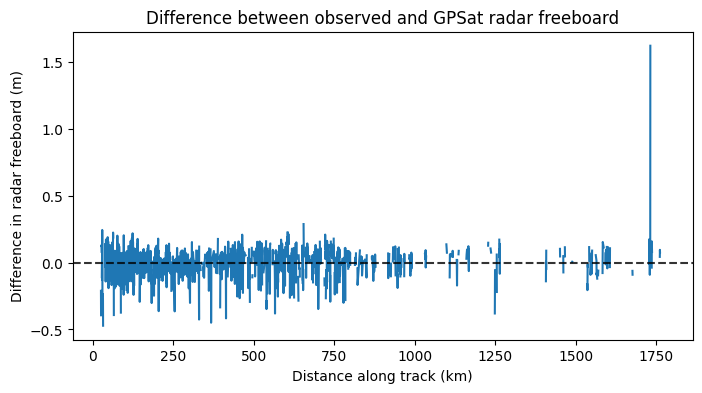

In [29]:
# Plot the difference in radar freeboard
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(111)
ax.plot(rfb_df['dist_along_track'] / 1000, rfb_df['rfb_diff'])
ax.axhline(y=0, color='k', linestyle='--', alpha=0.8)
ax.set_xlabel('Distance along track (km)')
ax.set_ylabel('Difference in radar freeboard (m)')
ax.set_title('Difference between observed and GPSat radar freeboard')
plt.show()